In [27]:
import numpy as np
from cartopy.io.shapereader import Reader
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tf 
import numpy as np
from matplotlib.font_manager import FontProperties
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import xarray as xr
import os
from scipy.interpolate import interp1d, interp2d, griddata
import rasterio
from rasterio.plot import show
from rasterio.windows import from_bounds
from rasterio.transform import from_origin

In [28]:
df_posi=pd.read_csv(r'E:\0000000000\组内工作\202407江淮梅雨\code\小论文代码 五年\df_posi_02—10.csv')



In [29]:
gauge_pre=np.load("guage_pre_all.npy")
# gauge_mean=np.nanmean(gauge_pre,axis=0)
# zero_indices =np.array( np.where(gauge_mean == 0)[0] )
# df_posi = df_posi.drop(index=zero_indices)

In [30]:
df_posi[df_posi['num']>=10]

,indexi,indexj,lons,lats,num
47,0,19,114.9700,30.1000,15
48,0,19,114.9450,30.1792,15
49,0,19,114.9706,30.1331,15
50,0,19,114.9461,30.0514,15
51,0,19,114.9500,30.1333,15
...,...,...,...,...,...
7128,34,17,114.5986,36.8861,11
7129,34,17,114.5511,36.9547,11
7130,34,17,114.5769,36.9089,11
7131,34,17,114.4981,36.8547,11


In [31]:
fenbian=0.2
p=int(7/fenbian)
q=int(11/fenbian)
num=np.zeros((p,q))
for i in range(len(df_posi["lons"])):
    # if i in zero_indices:
    #     continue
    x=int((df_posi["lons"][i]-111)/fenbian)
    y=int((df_posi["lats"][i]-30)/fenbian)
    num[y,x]=num[y,x]+1

In [32]:
# np.save('num_station_gauge.npy',num)
# num=np.load('num_station_gauge.npy')

In [33]:
num[num>=40].shape

(1,)

In [34]:
df_filtered=df_posi[df_posi['num']>=41]
# groups = df_filtered.groupby(['indexi', 'indexj'])

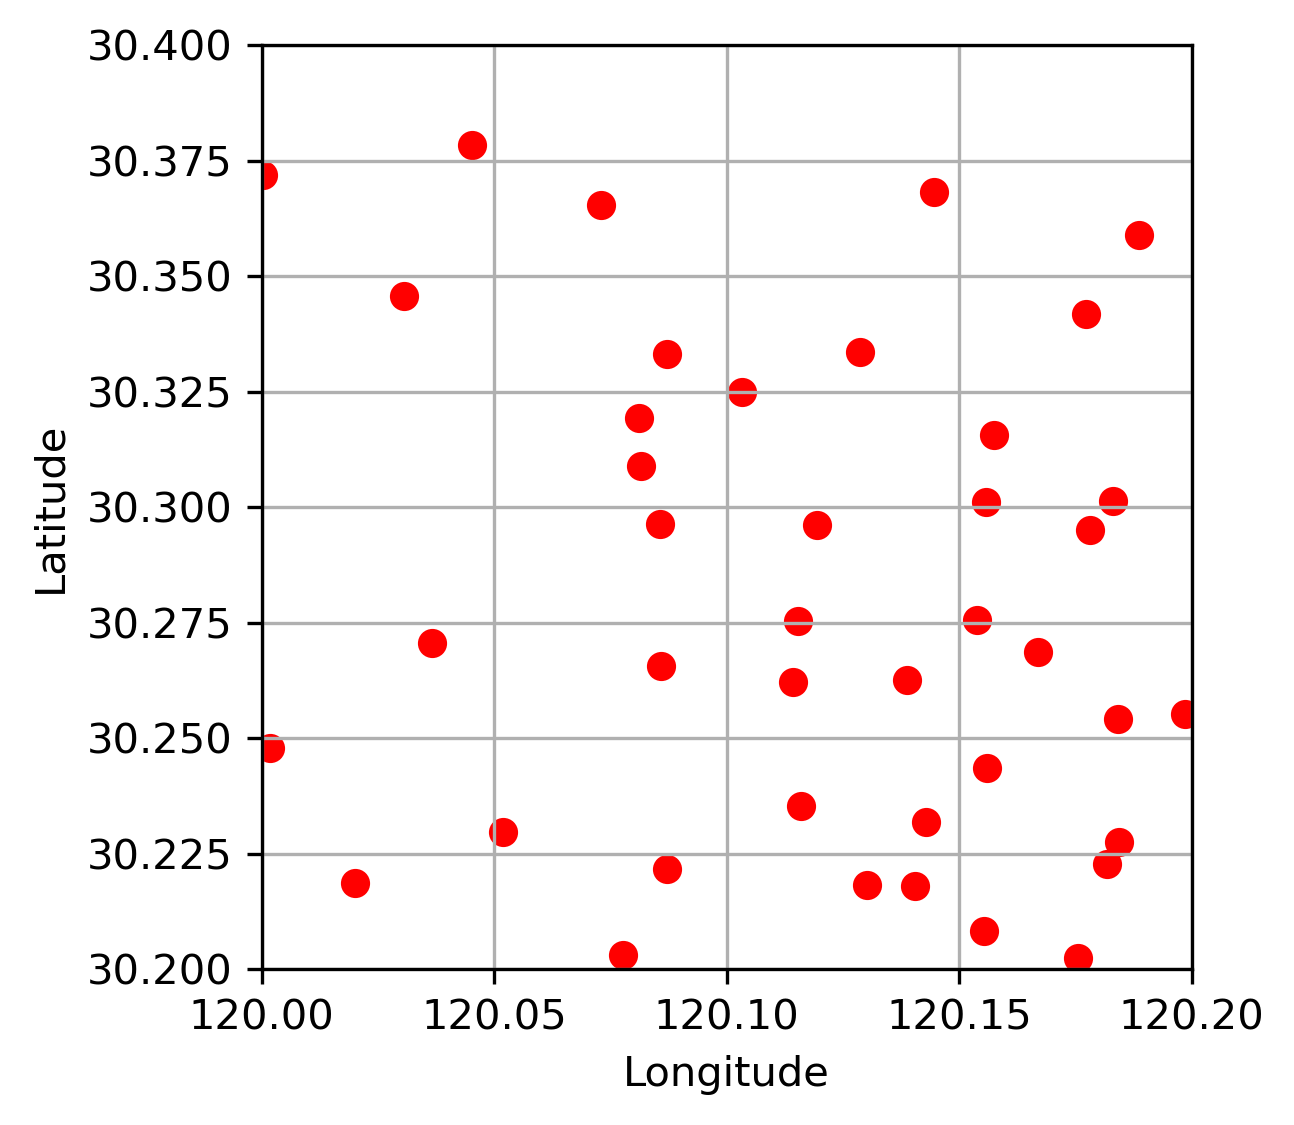

In [35]:
import matplotlib.pyplot as plt

# 假设你的数据是 df_filtered
plt.figure(figsize=(4,4),dpi=300)
plt.scatter(df_filtered["lons"], df_filtered["lats"], c="red", marker="o")

# 设置显示范围
plt.xlim(120, 120.2)
plt.ylim(30.2, 30.4)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
# plt.title(" (120-120.2°, 30.2-30.4°)")
plt.grid(True)
plt.show()


In [37]:
df_filtered.shape

(41, 5)

In [8]:

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']  # 确保优先使用 Arial

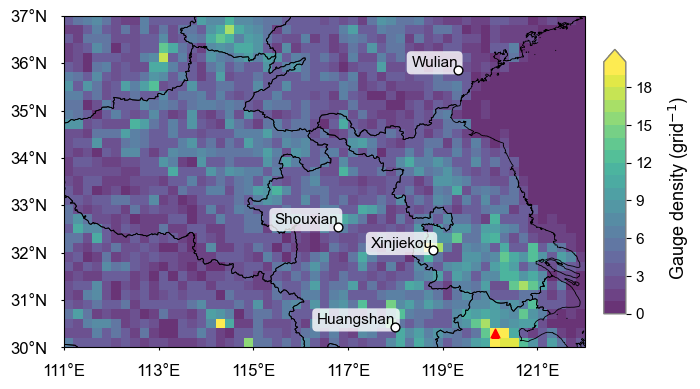

In [ ]:
shp_path = r"E:\0000000000\map_data\bou2_4p.dbf"

# --创建画图空间
proj = ccrs.PlateCarree()  # 创建坐标系
fig = plt.figure(figsize=(24, 20))  # 创建页面

# 创建子图布局，调整子图大小比例
# 使用gridspec控制子图大小比例，两个子图都位于中列
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, height_ratios=[2.5,0.8], width_ratios=[1, 1, 1.], 
              hspace=0.2, wspace=0.2,
              left=0.05, right=0.95, top=0.9, bottom=0.58)
ax1 = fig.add_subplot(gs[0, 1], projection=proj)  # ✅ 使用gs
ax2 = fig.add_subplot(gs[1, 1])   
    
# ax1 = plt.subplot2grid((2, 3), (0, 1), projection=proj)  # 地图位于第一行中列
# ax2 = plt.subplot2grid((2, 3), (1, 1))  # 直方图位于第二行中列
# 在subplot2grid中直接指定height_ratios和width_ratios
# ax1 = plt.subplot2grid((2, 3), (0, 1), projection=proj,
#                        height_ratios=[1.5, 0.5], width_ratios=[1, 0.7, 1.5])
# ax2 = plt.subplot2grid((2, 3), (1, 1),
#                        height_ratios=[1.5, 0.5], width_ratios=[1, 0.7, 1.5])

# --绘制地图子图 (ax1)
provinces = cfeat.ShapelyFeature(Reader(shp_path).geometries(), proj, edgecolor='k', facecolor='none')
ax1.add_feature(provinces, lw=0.6, zorder=2)

# --设置地图范围和刻度
ax1.set_extent([111, 122, 30, 37], crs=ccrs.PlateCarree())
ax1.set_yticks(np.arange(30, 37+1, 1), crs=ccrs.PlateCarree())
ax1.xaxis.set_major_formatter(LongitudeFormatter())
ax1.yaxis.set_major_formatter(LatitudeFormatter())
ax1.tick_params(labelcolor='k', labelsize=12, length=2, pad=10)
ax1.set_xticks(np.arange(111, 122+1, 2), crs=ccrs.PlateCarree())

# --定义自定义colormap (使用更美观的配色方案)
# 选择viridis配色方案，色彩过渡更自然
cmap = plt.get_cmap('viridis')  # 可选: 'viridis','plasma', 'inferno', 'magma', 'cividis'
norm = mcolors.BoundaryNorm(boundaries=range(0,21,1), ncolors=cmap.N)

# 绘制gauge density数据
im = ax1.imshow(num, origin='lower', transform=proj, extent=[111, 122, 30, 37], cmap=cmap, norm=norm,alpha=0.8)

# --添加colorbar (优化样式)
cb = plt.colorbar(im, ax=ax1, extend='max', shrink=0.6, aspect=12, pad=0.03)
cb.set_label('Gauge density (grid$^{-1}$)', fontsize=13, labelpad=10)
cb.ax.tick_params(labelsize=11)
cb.minorticks_off()
# 设置colorbar边框
cb.outline.set_linewidth(1)
cb.outline.set_edgecolor('gray')

# 添加散点和标签 (优化样式)
# 使用更大更明显的标记点
ax1.scatter(116.7833, 32.55, color='white', s=40, marker='o', edgecolors='black', linewidth=1, zorder=10)
ax1.text(116.7833, 32.55, 'Shouxian', fontsize=11, ha='right', va='bottom', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))

ax1.scatter(118.7875, 32.0453, color='white', s=40, marker='o', edgecolors='black', linewidth=1, zorder=10)
ax1.text(118.7875, 32.0453, 'Xinjiekou', fontsize=11, ha='right', va='bottom',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))

ax1.scatter(117.9978, 30.4311, color='white', s=40, marker='o', edgecolors='black', linewidth=1, zorder=10)
ax1.text(117.9978, 30.4311, 'Huangshan', fontsize=11, ha='right', va='bottom',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))

ax1.scatter(119.3228, 35.8608, color='white', s=40, marker='o', edgecolors='black', linewidth=1, zorder=10)
ax1.text(119.3228, 35.8608, 'Wulian', fontsize=11, ha='right', va='bottom',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))

# ax1.set_title(f"(a) Gauge density", loc='left', fontsize=16,  pad=15)

ax1.scatter(120.100	,30.3, color='red', s=40, marker='^', edgecolors='red', linewidth=1, zorder=5)


# # --绘制频数直方图 (ax2) - 数量图而非PDF
# # 将num数据展平为一维数组
# num_flat = num.flatten()
# # 移除可能的NaN值
# num_flat = num_flat[~np.isnan(num_flat)]

# # 处理数据：将大于16的值合并为一个类别
# num_processed = num_flat.copy()
# num_processed[num_processed > 15] = 16  # 将所有>16的值设为17作为合并类别

# # 创建自定义bins：0-16各为一个bin，17为合并的>16类别
# bins_custom = list(range(0, 16)) + [16, 17]  # 0,1,2,...,16,17,18
# bins_edges = np.array(bins_custom) - 0.5  # 调整边界使得整数值在bin中心

# # 绘制频数直方图
# n, bins, patches = ax2.hist(num_processed, bins=bins_edges, density=False, alpha=0.7, 
#                            color='steelblue', edgecolor='white', linewidth=0.8)

# # 为直方图添加渐变色效果
# for i, p in enumerate(patches):
#     p.set_facecolor(plt.cm.viridis(i / len(patches)))

# total_count = len(num_flat)
# greater_than_16_count = len(num_flat[num_flat > 15])

# ax2.set_xlabel('Gauge density (grid$^{-1}$)', fontsize=13, )
# ax2.set_ylabel('Frequency', fontsize=13, )
# ax2.set_title(f"(b) Frequency of gauge density (Total: {total_count} grids)", loc='left', fontsize=16,  pad=15)

# # 美化网格和边框
# ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)
# ax2.spines['left'].set_linewidth(0.8)
# ax2.spines['bottom'].set_linewidth(0.8)

# # 调整刻度样式
# ax2.tick_params(axis='both', which='major', labelsize=11, colors='black')
# ax2.set_xlim(left=-0.5, right=16.5)  # 调整x轴范围

# # 自定义x轴刻度标签
# x_ticks = list(range(0, 16)) + [16]
# x_labels = list(range(0, 16)) + ['≥16']
# ax2.set_xticks(x_ticks)
# ax2.set_xticklabels(x_labels)

# # 在每个柱子上显示频数
# for i, v in enumerate(n):
#     if v > 0:  # 只在有数据的柱子上显示数字
#         x_pos = (bins[i] + bins[i+1]) / 2
#         ax2.text(x_pos, v + max(n)*0.01, 
#                 f'{int(v)}', ha='center', va='bottom', fontsize=9, color='black')

# plt.tight_layout()  # 使用gridspec后不需要额外的pad
# plt.savefig('fig1.png')
plt.show()